In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns

In [2]:
df = pd.read_csv("dataset_agro_rd_validado.csv")
print(df.columns)

# Ver las primeras filas para confirmar estructura
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'dataset_agro_rd_validado.csv'

In [ ]:
# Crear la columna 'fecha' uniendo Año y Mes (y asignando día 1)
df['fecha'] = pd.to_datetime(dict(year=df['Año'], month=df['Mes'], day=1))

# Calcular la 'Venta Total' (Producción * Precio)
df['Venta_Total'] = df['Producción_Total'] * df['Precio_Unitario']

In [ ]:
# ANÁLISIS 1: Producto con MEJOR VENTA (Ingresos)
# ---------------------------------------------------------
print("--- TOP 5 PRODUCTOS POR VENTA TOTAL ACUMULADA ---")
top_ventas = df.groupby('Producto')['Venta_Total'].sum().sort_values(ascending=False)
print(top_ventas.head(5))
print("\n")


--- TOP 5 PRODUCTOS POR VENTA TOTAL ACUMULADA ---
Producto
Cilantro              1.379771e+11
Tomate Industrial     2.270658e+10
Tomate de Ensalada    1.732797e+10
Ají Cubanela          1.130190e+10
Lechosa               1.112824e+10
Name: Venta_Total, dtype: float64




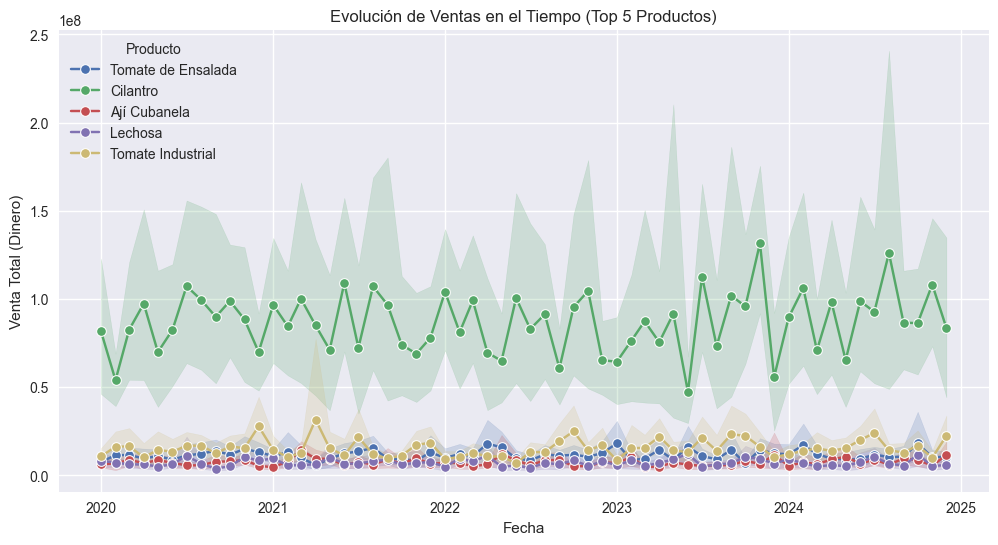

In [ ]:
# Gráfico 1: Evolución de ventas en el tiempo (Solo los top 5 para no saturar)
top_5_productos_lista = top_ventas.head(5).index
df_top_ventas = df[df['Producto'].isin(top_5_productos_lista)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_top_ventas, x='fecha', y='Venta_Total', hue='Producto', marker='o')
plt.title('Evolución de Ventas en el Tiempo (Top 5 Productos)')
plt.ylabel('Venta Total (Dinero)')
plt.xlabel('Fecha')
plt.legend(title='Producto')
plt.show()

In [ ]:
# ANÁLISIS 2: Producto con MAYOR VARIACIÓN DE PRECIO
# ---------------------------------------------------------
# Usamos Desviación Estándar (std) para medir qué tanto varía el precio
print("--- TOP 5 PRODUCTOS CON MAYOR INESTABILIDAD DE PRECIO (Desviación Estándar) ---")
variacion_precio = df.groupby('Producto')['Precio_Unitario'].std().sort_values(ascending=False)
print(variacion_precio.head(5))

--- TOP 5 PRODUCTOS CON MAYOR INESTABILIDAD DE PRECIO (Desviación Estándar) ---
Producto
Cilantro    832.383822
Tabaco      733.120719
Papa        714.846912
Coliflor    714.665178
Arroz       713.487272
Name: Precio_Unitario, dtype: float64


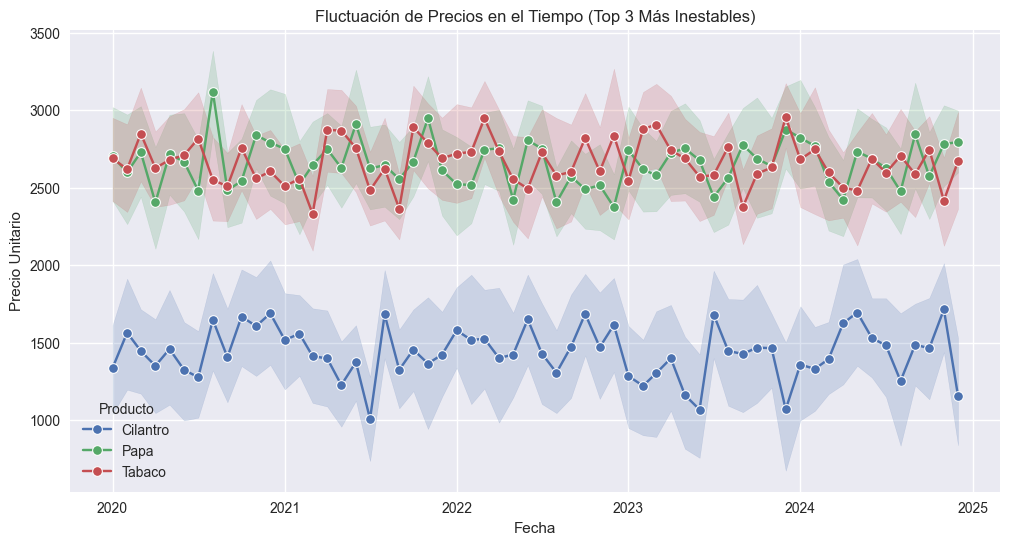

In [ ]:
# Gráfico 2: Histórico de precios de los 3 productos más inestables
top_3_inestables = variacion_precio.head(3).index
df_inestables = df[df['Producto'].isin(top_3_inestables)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_inestables, x='fecha', y='Precio_Unitario', hue='Producto', marker='o')
plt.title('Fluctuación de Precios en el Tiempo (Top 3 Más Inestables)')
plt.ylabel('Precio Unitario')
plt.xlabel('Fecha')
plt.legend(title='Producto')
plt.show()